# Trabajo Práctico AA1 - Clasificación

In [11]:
# manipulación, visualización y modelado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# separación de datos, modelos y métricas.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc

# preprocesamiento.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Carga dataset

In [12]:
# Cargamos el dataset
df_original = pd.read_csv("/content/weatherAUS_2026C1.csv")
df_original.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [13]:
#copiamos el dataset para mantener el original
df = df_original.copy()

In [14]:
# revisamos las columnas
df.columns

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='object')

In [15]:
# cantidad de filas y columnas
df.shape

(145412, 25)

In [16]:
# revisamos tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

In [23]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1484
MaxTemp,1253
Rainfall,3260
Evaporation,62754
Sunshine,69796
WindGustDir,10316
WindGustSpeed,10253
WindDir9am,10562


Se detectan valores faltantes en varias columnas, por lo que será necesario tratarlo según el caso.

In [17]:
df.describe()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainfallTomorrow
count,145412.000000,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000
mean,72728.184393,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242
std,41990.722236,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084
min,0.000000,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000
25%,36362.750000,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,72727.500000,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,109093.250000,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,145458.000000,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000


In [18]:
df = df.drop(columns=["Unnamed: 0"])

La columna "Unnamed: 0" parece ser un índice guardado en el archivo CSV, por lo que no representa una variable climática útil para la predicción. Por este motivo se elimina del análisis.

In [20]:
df = df.drop(columns=["RainfallTomorrow"])

In [22]:
# verificamos que hayan sido eliminadas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

La columna "RainfallTomorrow" no se utiliza como variable predictora porque contiene información asociada al día siguiente. Como el objetivo es predecir a las 23:59 hs si al día siguiente lloverá o no, esta información no estaría disponible al momento de realizar la predicción. Usarla produciría fuga de datos.

In [27]:
# revisamos los valores de la variable objetivo
df["RainTomorrow"].value_counts(dropna=False)

,count
RainTomorrow,
No,110281
Yes,31872
NaN,3259


In [28]:
# Calculamos la proporción de cada clase
df["RainTomorrow"].value_counts(normalize=True, dropna=False)

,proportion
RainTomorrow,
No,0.758404
Yes,0.219184
NaN,0.022412


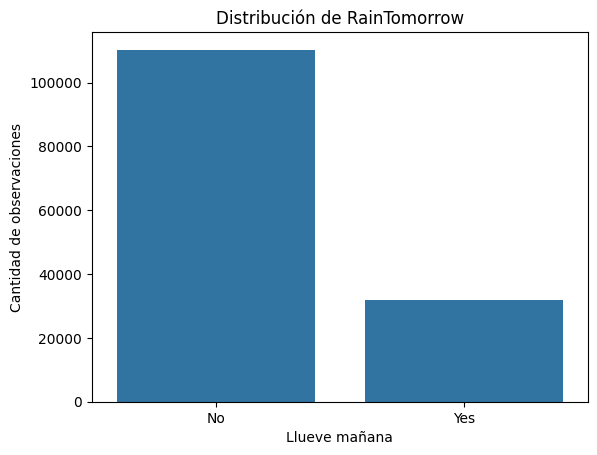

In [30]:
# Graficamos la distribución de la variable objetivo
sns.countplot(data=df, x="RainTomorrow")
plt.title("Distribución de RainTomorrow")
plt.xlabel("Llueve mañana")
plt.ylabel("Cantidad de observaciones")
plt.show()

La variable objetivo del problema es "RainTomorrow", que indica si al día siguiente llovió o no. En distribución observamos que la clase "No" aparece con mucha mayor frecuencia que la clase "Yes". Por ende el dataset está desbalanceado, por este motivo, además de accuracy, será necesario observar métricas como precision, recall y F1-score, especialmente para la clase "Yes". Sino el modelo puede no aprender a detectar bien los dias que si llueve


In [31]:
# eliminamos filas donde la variable objetivo no tiene valor
df = df.dropna(subset=["RainTomorrow"])

In [32]:
# verificamos
df["RainTomorrow"].value_counts(dropna=False)

,count
RainTomorrow,
No,110281
Yes,31872


Las filas con valores faltantes en "RainTomorrow" se eliminan porque esta columna es la variable objetivo. Si no se conoce si al día siguiente llovió o no, esa observación no puede utilizarse para entrenar ni evaluar un modelo supervisado.